In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA RTX 4500 Ada Generation


In [3]:
PROJECT_ROOT = Path.cwd().parent

processed_path = PROJECT_ROOT / "data" / "processed"

X_train = np.load(processed_path / "X_train.npy")
X_test = np.load(processed_path / "X_test.npy")

y_train = np.load(processed_path / "y_train.npy")
y_test = np.load(processed_path / "y_test.npy")

print(X_train.shape)
print(X_test.shape)

(90008, 512)
(22503, 512)


In [4]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape)
print(y_train.shape)

torch.Size([90008, 512])
torch.Size([90008])


In [5]:
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 1407
Test batches: 352


In [6]:
class_counts = torch.bincount(y_train)

print("Class counts:", class_counts)

class_weights = class_counts.sum() / (2 * class_counts.float())

print("Class weights:", class_weights)

class_weights = class_weights.to(device)

Class counts: tensor([72445, 17563])
Class weights: tensor([0.6212, 2.5624])


In [7]:
# ==========================
# Hyperparameters
# ==========================

INPUT_LENGTH = 512
D_MODEL = 32
NHEAD = 2
NUM_LAYERS = 2
NUM_CLASSES = 2

DROPOUT = 0.2

LEARNING_RATE = 1e-3
EPOCHS = 20

In [8]:
import math

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [9]:
class ECGTransformer(nn.Module):

    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(1, D_MODEL)

        self.position = PositionalEncoding(D_MODEL)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,
            nhead=NHEAD,
            dropout=DROPOUT,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=NUM_LAYERS
        )

        self.classifier = nn.Sequential(
            nn.Linear(D_MODEL, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):

        x = x.unsqueeze(-1)

        x = self.embedding(x)

        x = self.position(x)

        x = self.encoder(x)

        x = x.mean(dim=1)

        return self.classifier(x)

In [10]:
model = ECGTransformer().to(device)

print(model)

ECGTransformer(
  (embedding): Linear(in_features=1, out_features=32, bias=True)
  (position): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in

In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [12]:
X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)

with torch.no_grad():

    output = model(X_batch)

print("Input :", X_batch.shape)
print("Output:", output.shape)

Input : torch.Size([64, 512])
Output: torch.Size([64, 2])


In [13]:
PROJECT_ROOT = Path.cwd().parent

CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints"

CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)

print(CHECKPOINT_PATH)

/home/pesu-rf/Downloads/ecg_ssm/checkpoints


In [14]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for X, y in loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.argmax(1)

        total += y.size(0)

        correct += (predicted == y).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for X, y in loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(X)

        loss = criterion(outputs, y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.argmax(1)

        total += y.size(0)

        correct += (predicted == y).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [16]:
def evaluate(model, loader):

    model.eval()

    predictions = []
    labels = []

    with torch.no_grad():

        for X, y in loader:

            X = X.to(device)

            outputs = model(X)

            preds = outputs.argmax(1).cpu()

            predictions.extend(preds.numpy())

            labels.extend(y.numpy())

    return np.array(labels), np.array(predictions)

In [17]:
train_losses = []
train_accs = []

best_acc = 0

for epoch in range(EPOCHS):

    loss, acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    train_losses.append(loss)
    train_accs.append(acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {loss:.4f} | "
        f"Accuracy: {acc:.4f}"
    )

    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            CHECKPOINT_PATH / "best_transformer.pth"
        )

print("Training Finished!")

Epoch 1/20 | Loss: 0.2802 | Accuracy: 0.8880
Epoch 2/20 | Loss: 0.1600 | Accuracy: 0.9484
Epoch 3/20 | Loss: 0.1298 | Accuracy: 0.9572
Epoch 4/20 | Loss: 0.1122 | Accuracy: 0.9615
Epoch 5/20 | Loss: 0.1004 | Accuracy: 0.9660
Epoch 6/20 | Loss: 0.0919 | Accuracy: 0.9696
Epoch 7/20 | Loss: 0.0868 | Accuracy: 0.9707
Epoch 8/20 | Loss: 0.0828 | Accuracy: 0.9726
Epoch 9/20 | Loss: 0.0795 | Accuracy: 0.9738
Epoch 10/20 | Loss: 0.0771 | Accuracy: 0.9737
Epoch 11/20 | Loss: 0.0752 | Accuracy: 0.9749
Epoch 12/20 | Loss: 0.0711 | Accuracy: 0.9764
Epoch 13/20 | Loss: 0.0690 | Accuracy: 0.9781
Epoch 14/20 | Loss: 0.0672 | Accuracy: 0.9782
Epoch 15/20 | Loss: 0.0664 | Accuracy: 0.9783
Epoch 16/20 | Loss: 0.0640 | Accuracy: 0.9794
Epoch 17/20 | Loss: 0.0622 | Accuracy: 0.9797
Epoch 18/20 | Loss: 0.0611 | Accuracy: 0.9806
Epoch 19/20 | Loss: 0.0596 | Accuracy: 0.9807
Epoch 20/20 | Loss: 0.0565 | Accuracy: 0.9811
Training Finished!


In [18]:
model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH / "best_transformer.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [19]:
y_true, y_pred = evaluate(model, test_loader)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

Accuracy : 0.9786250722125939
Precision: 0.9189884269181312
Recall   : 0.9765429287178319
F1 Score : 0.9468919068124103


[[17734   378]
 [  103  4288]]


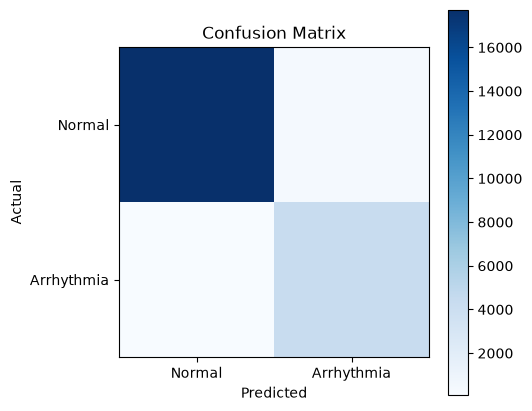

In [20]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks([0,1],["Normal","Arrhythmia"])

plt.yticks([0,1],["Normal","Arrhythmia"])

plt.show()

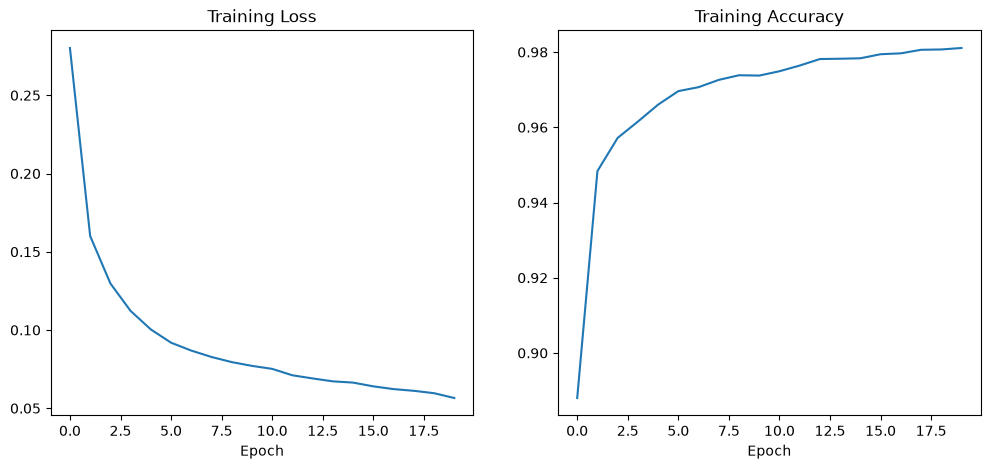

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")

plt.subplot(1,2,2)
plt.plot(train_accs)
plt.title("Training Accuracy")
plt.xlabel("Epoch")

plt.show()

In [22]:
from pathlib import Path
import torch

PROJECT_ROOT = Path.cwd().parent

CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints"

CHECKPOINT_PATH.mkdir(exist_ok=True)

torch.save(
    model.state_dict(),
    CHECKPOINT_PATH / "best_transformer.pth"
)

print("Transformer saved successfully!")

Transformer saved successfully!
